# Chapter 03 회귀 알고리즘과 모델 규제
## 03-02 선형 회귀
### k-최근접 이웃의 한계

In [2]:
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [3]:
from sklearn.model_selection import train_test_split

# 훈련 세트와 테스트 세트로 나눔
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)

# 훈련 세트와 테스트 세트를 2차원 배열로 바꿈
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [8]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

# k-최근접 이웃 회귀 모델 훈련
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

In [6]:
print(knr.predict([[50]])) # 이 모델은 50cm 농어의 무게를 1,033g 정도로 예측

[1033.33333333]


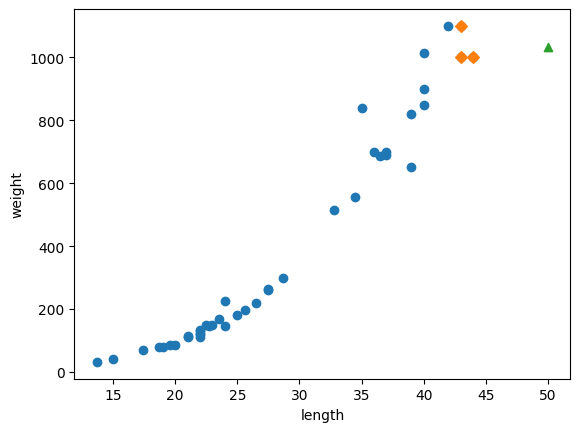

In [11]:
import matplotlib.pyplot as plt

# 50cm 농어의 이웃
distances, indexes = knr.kneighbors([[50]])

# 훈련 세트의 산점도
plt.scatter(train_input, train_target)

# 훈련 세트 중 이웃 샘플만
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 농어 데이터
plt.scatter(50, 1033, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

* 위 산점도를 보면 길이가 커질수록 농어의 무게가 증가하는 경향이 있음.

In [12]:
print(np.mean(train_target[indexes])) # 모델이 예측했던 값과 정확히 일치

1033.3333333333333


* k-최근접 이웃 회귀는 가장 가까운 샘플을 찾아 타깃을 평균 -> 새로운 샘플이 훈련 세트의 범위를 벗어나면 엉뚱한 값을 예측할 수 있음. -> 결국 k-최근접 이웃을 사용해 이 문제를 해결하렬면 가장 큰 경우의 수가 포함되도록 해야 하는데? -> 다른 알고리즘을 찾아보자!


> 머신러닝 모델은 주기적으로 훈련해야 합니다.
> * 사실 머신러닝 모델은 한 번 만들고 끝나는 프로그램이 아님. 시간과 환경이 변화하면서 데이터도 바뀌기 때문에 주기적으로 새로운 훈련 데이터로 모델을 다시 훈련해야 함. 예를 들어 배달 음식이 도착하는 시간을 예측하는 모델은 배달원이 바뀌거나 도로 환경이 변할 수 있기 때문에 새로운 데이터를 사용해 반복적으로 훈련해야 함.



### 선형 회귀
* 선형이란 말에서 짐작할 수 있듯이 **특성이 하나**인 경우 어떤 직선을 학습하는 알고리즘.
* 그 특성을 가장 잘 나타낼 수 있는 직선!

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# 선형 회귀 모델을 훈련
lr.fit(train_input, train_target)

# 50cm 농어에 대해 예측
print(lr.predict([[50]]))

[1241.83860323]


In [14]:
print(lr.coef_, lr.intercept_) # 기울기와 y 절편

[39.01714496] -709.0186449535477




> coef_와 intercept_를 머신러닝 알고리즘이 찾은 값이라는 의미로 모델 파라미터(model parameter)라고 부름. 많은 머신러닝 알고리즘의 훈련 과정은 최적의 모델 파라미터를 찾는 것과 같음. 이를 **모델 기반 학습**이라고 부름. 앞서 사용한 k-최근접 이웃에는 모델 파라미터가 없음. 이를 **사례 기반 학습**이라고 부름.

In [15]:
print(lr.score(train_input, train_target)) # 훈련 세트
print(lr.score(test_input, test_target)) # 테스트 세트

0.939846333997604
0.8247503123313558


* 훈련 세트와 테스트 세트의 점수가 조금 차이 나는데, 과대적합되었다고 할 수는 없음. 훈련 세트의 점수도 높지 않아서 전체적으로 과소적합되었다고 볼 수 있음.

### 다항 회귀

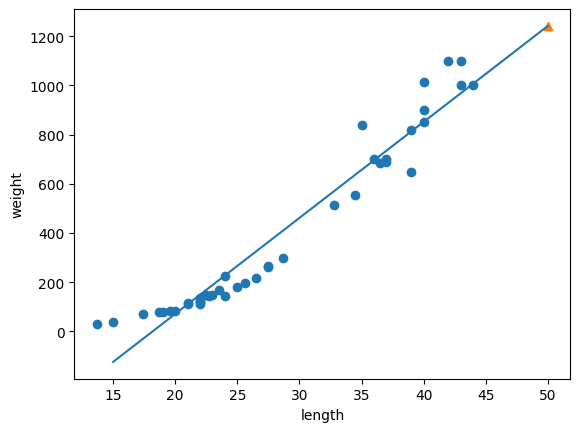

In [16]:
# 훈련 세트의 산점도
plt.scatter(train_input, train_target)

# 15에서 50까지 1차 방정식 그래프
plt.plot([15, 50], [15*lr.coef_+lr.intercept_, 50*lr.coef_+lr.intercept_])

# 50cm 농어 데이터
plt.scatter(50, 1241.8, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

* 위 직선대로 예측하면 농어의 무게가 0g 이하로 내려갈 텐데 현실에서는 있을 수 없음. -> 농어의 길이와 무게에 대한 최적의 곡선을 찾아야 함.
* 2차 방정식의 그래프를 그리려면 길이를 제곱한 항이 훈련 세트에 추가되어야 함.

In [18]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))
print(train_poly.shape, test_poly.shape) # 길이 제곱을 추가했기 때문에 훈련 세트와 테스트 세트 모두 열이 2개가 됨

(42, 2) (14, 2)


In [19]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [20]:
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


* 위 모델은 다음과 같은 그래프를 학습했음
  * $무게=1.01 \times 길이^{2}-21.6 \times 길이 + 116.05$
* 이런 방정식을 다항식이라 부르며 다항식을 사용한 선형 회귀를 **다항 회귀polynomial regression**라 부름.

In [21]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


* 훈련 세트와 테스트 세트에 대한 점수가 크게 높아졌음. **하지만 여전히 테스트 세트의 점수가 조금 더 높은 것으로 보아 과소적합 상태. -> 더 복잡한 모델 필요!**